# 🧠 MRI Image Enhancement and Tumor Detection
## Notebook 2: High-Precision U-Net Tumor Segmentation Training
**Prerequisite:** Run Notebook 1 first to cache enhanced images.

---
### Objectives
1. Verify GPU availability and environment
2. Load the 4,793 segmentation pairs (enhanced images + binary masks)
3. Train U-Net with Compound Tversky-Focal + BCE Loss (pos_weight=10)
4. Plot convergence curves and visualize segmentation overlays
5. Save best checkpoint to `checkpoints/unet/best_unet_enhanced.pth`

> 💡 **Expected training time:** ~35–50 minutes on Colab T4 GPU (25 epochs × ~210 batches)

In [1]:
# ── Cell 1: Environment Setup & Hardware Profile ───────────────────────────
from __future__ import annotations
import os, sys

# ── Google Drive mount (Colab only — skipped automatically when running locally) ─
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    PROJECT_PATH = "/content/drive/MyDrive/Brain_Tumor_Project"
except ImportError:
    _cwd = os.path.dirname(__file__) if '__file__' in globals() else os.getcwd()
    PROJECT_PATH = os.path.abspath(os.path.join(_cwd, '..') if os.path.basename(_cwd) == 'notebooks' else _cwd)

assert os.path.exists(PROJECT_PATH), f"Project not found at {PROJECT_PATH}"
os.chdir(PROJECT_PATH)
sys.path.insert(0, PROJECT_PATH)

try:
    import albumentations
    import pandas
except ImportError:
    import subprocess, sys as _sys
    print("Installing requirements.txt (Dependencies missing)...")
    subprocess.check_call([_sys.executable, "-m", "pip", "install", "-r", "requirements.txt", "-q"])

# ── Dynamic hardware profile ────────────────────────────────────────────────
from utils.device_config import get_system_execution_profile
profile = get_system_execution_profile()
print(f"🖥️ System Profile: {profile['gpu_name']} ({profile['vram_gb']} GB VRAM) | RAM: {profile['total_ram_gb']} GB | Workers: {profile['num_workers']}")

import torch
device = profile["device"]
if profile["has_cuda"]:
    torch.cuda.empty_cache()
print(f"✅ PyTorch {torch.__version__} | Device: {device} | AMP: {profile['use_amp']}")

🖥️ System Profile: NVIDIA GeForce RTX 3050 6GB Laptop GPU (6.0 GB VRAM) | RAM: 15.23 GB | Workers: 0
✅ PyTorch 2.5.1+cu121 | Device: cuda | AMP: True


In [2]:
# ── Cell 2: Verify Prerequisites ─────────────────────────────────────────────
import os, json

META_PATH = "data/brisc/brisc_metadata.json"
CACHE_DIR = "data/cached_enhanced"

assert os.path.exists(META_PATH), (
    f"BRISC metadata not found.\nPlease run Notebook 1 first!"
)
with open(META_PATH) as f:
    meta = json.load(f)

seg_count = meta["segmentation_count"]
cached    = len([f for f in os.listdir(CACHE_DIR) if not f.startswith(".")])

print(f"✅ Segmentation pairs available : {seg_count:,}")
print(f"✅ Cached enhanced images       : {cached:,}")
assert seg_count >= 4700, "Too few segmentation pairs — re-run Notebook 1"
print("\n✅ All prerequisites satisfied. Ready to train.")

✅ Segmentation pairs available : 4,793
✅ Cached enhanced images       : 6,001

✅ All prerequisites satisfied. Ready to train.


In [3]:
# ── Cell 3: DataLoader Setup (profile-driven batch size & workers) ───────────
import json, random
import torch
from torch.utils.data import DataLoader
from data.dataset_preprocessor import BRISCSegmentationDataset
from utils.device_config import get_system_execution_profile

# Hardware-adaptive: matches the same values the CLI training script uses.
# Override by setting BATCH_SIZE / NUM_WORKERS manually after this cell.
profile     = get_system_execution_profile()
BATCH_SIZE  = profile["batch_size"]
NUM_WORKERS = profile["num_workers"]
PIN_MEMORY  = profile["pin_memory"]
PERSISTENT  = profile["persistent_workers"]
TRAIN_SPLIT  = 0.70
INPUT_TYPE   = "enhanced"   # "enhanced" uses WPT→LMMSE→CLAHE cached images

with open("data/brisc/brisc_metadata.json") as f:
    meta = json.load(f)

all_pairs = meta["segmentation"]
random.seed(42)
random.shuffle(all_pairs)

n_train = int(len(all_pairs) * TRAIN_SPLIT)
train_pairs = all_pairs[:n_train]
val_pairs   = all_pairs[n_train:]

# BRISCSegmentationDataset handles:
#  - enhanced image lookup in data/cached_enhanced/
#  - ImageNet normalization (μ=0.485, σ=0.229)
#  - Albumentations augmentations (train only)
#  - Binary mask binarization (>0.5 threshold)
train_ds = BRISCSegmentationDataset(train_pairs, split="train")
val_ds   = BRISCSegmentationDataset(val_pairs,   split="val")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS,
                          persistent_workers=PERSISTENT)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS,
                          persistent_workers=PERSISTENT)

print(f"✅ Train: {len(train_ds):,} images → {len(train_loader)} batches/epoch")
print(f"✅ Val  : {len(val_ds):,} images → {len(val_loader)} batches/epoch")
print(f"✅ Batch size: {BATCH_SIZE} | Workers: {NUM_WORKERS} | Pin memory: {PIN_MEMORY}")

✅ Train: 3,355 images → 420 batches/epoch
✅ Val  : 1,438 images → 180 batches/epoch
✅ Batch size: 8 | Workers: 0 | Pin memory: True


In [4]:
# ── Cell 4: Model, Loss, Optimizer Configuration ─────────────────────────────
import torch, torch.nn as nn, torch.optim as optim

from segmentation.unet_model import UNet
from segmentation.metrics import TverskyFocalLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(n_channels=3, n_classes=1).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ U-Net | Trainable parameters: {n_params:,}")

# Compound loss: 40% BCE (with pos_weight=10 for class imbalance) + 60% Tversky-Focal
pos_weight = torch.tensor([10.0]).to(device)
bce_loss   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
tvk_loss   = TverskyFocalLoss(alpha=0.7, beta=0.3, gamma=0.75)

def criterion(logits, targets):
    return 0.4 * bce_loss(logits, targets) + 0.6 * tvk_loss(logits, targets)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.5, min_lr=1e-7
)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")

print(f"✅ Loss: 0.4×BCE(pos_weight=10) + 0.6×TverskyFocal(α=0.7, β=0.3, γ=0.75)")
print(f"✅ Optimizer: AdamW lr=1e-4 | Scheduler: ReduceLROnPlateau(patience=5)")
print(f"✅ Mixed Precision: {device.type == 'cuda'}")

✅ U-Net | Trainable parameters: 13,391,361
✅ Loss: 0.4×BCE(pos_weight=10) + 0.6×TverskyFocal(α=0.7, β=0.3, γ=0.75)
✅ Optimizer: AdamW lr=1e-4 | Scheduler: ReduceLROnPlateau(patience=5)
✅ Mixed Precision: True


In [5]:
# ── Cell 5: Training Loop (execute from CLI for cleaner output) ─────────────
# This launches train_unet.py as a subprocess so TQDM progress bars render correctly
import subprocess, sys

CMD = [
    sys.executable, "-m", "segmentation.train_unet",
    "--input_type", "enhanced",
    "--epochs",     "25",
    "--lr",         "0.0001",
]

print("🚀 Starting U-Net training...")
print(f"   Command: {' '.join(CMD)}\n")

proc = subprocess.Popen(CMD, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        text=True, bufsize=1, universal_newlines=True, encoding='utf-8')
for line in proc.stdout:
    print(line, end="")
proc.wait()

if proc.returncode == 0:
    print("\n✅ Training complete!")
else:
    raise RuntimeError(f"Training failed with exit code {proc.returncode}")

🚀 Starting U-Net training...
   Command: c:\Users\bhask\AppData\Local\Programs\Python\Python311\python.exe -m segmentation.train_unet --input_type enhanced --epochs 25 --lr 0.0001

ℹ️ [INFO] Hardware Profile → Device: cuda (NVIDIA GeForce RTX 3050 6GB Laptop GPU) | VRAM: 6.0 GB | RAM: 15.23 GB | Batch: 8 | Workers: 0 | AMP: True
ℹ️ [INFO] Using device: cuda
ℹ️ [INFO] Loaded 4793 segmentation pairs for training.

Epoch 01/25 [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 25/420 - Loss: 0.7444
Epoch 01/25 [███░░░░░░░░░░░░░░░░░░░░░░░░░░░] 50/420 - Loss: 0.7249
Epoch 01/25 [█████░░░░░░░░░░░░░░░░░░░░░░░░░] 75/420 - Loss: 0.7186
Epoch 01/25 [███████░░░░░░░░░░░░░░░░░░░░░░░] 100/420 - Loss: 0.7420
Epoch 01/25 [████████░░░░░░░░░░░░░░░░░░░░░░] 125/420 - Loss: 0.6732
Epoch 01/25 [██████████░░░░░░░░░░░░░░░░░░░░] 150/420 - Loss: 0.6711
Epoch 01/25 [████████████░░░░░░░░░░░░░░░░░░] 175/420 - Loss: 0.6144
Epoch 01/25 [██████████████░░░░░░░░░░░░░░░░] 200/420 - Loss: 0.6261
Epoch 01/25 [████████████████░░░░░░░░░░░░░░

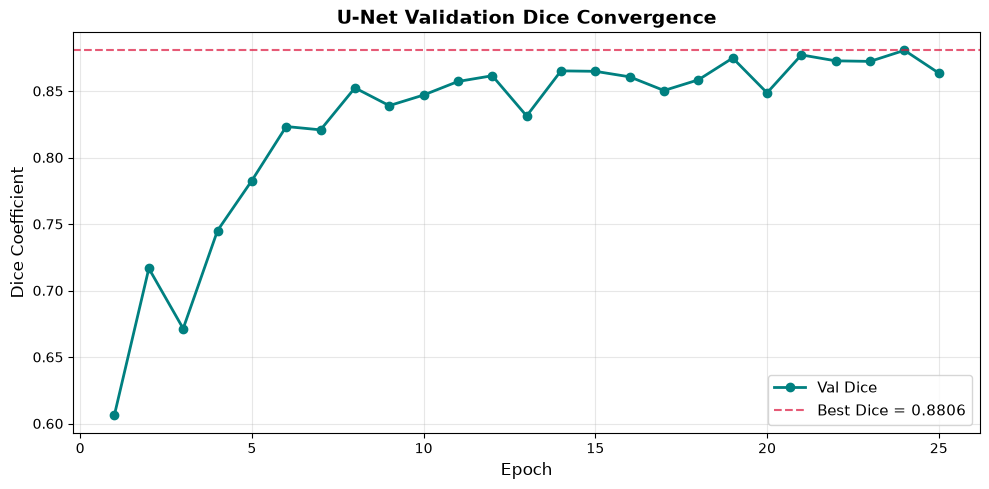

✅ Best Val Dice: 0.8806 at Epoch 24


In [6]:
# ── Cell 6: Training Curves ──────────────────────────────────────────────────
import json, os, matplotlib.pyplot as plt

HISTORY_FILE = "checkpoints/unet/unet_training_history_enhanced.json"

if not os.path.exists(HISTORY_FILE):
    print(f"⚠️  History file not found: {HISTORY_FILE}\nRun Cell 5 first.")
else:
    with open(HISTORY_FILE) as f:
        history = json.load(f)

    epochs   = [h["epoch"]    for h in history]
    val_dice = [h["val_dice"] for h in history]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, val_dice, "o-", color="teal", linewidth=2, label="Val Dice")
    ax.axhline(max(val_dice), ls="--", color="crimson", alpha=0.7,
               label=f"Best Dice = {max(val_dice):.4f}")
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Dice Coefficient", fontsize=12)
    ax.set_title("U-Net Validation Dice Convergence", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("reports/figures/unet_dice_curve.png", dpi=150)
    plt.show()
    print(f"✅ Best Val Dice: {max(val_dice):.4f} at Epoch {val_dice.index(max(val_dice)) + 1}")

✅ Loaded checkpoint: checkpoints/unet/best_unet_enhanced.pth


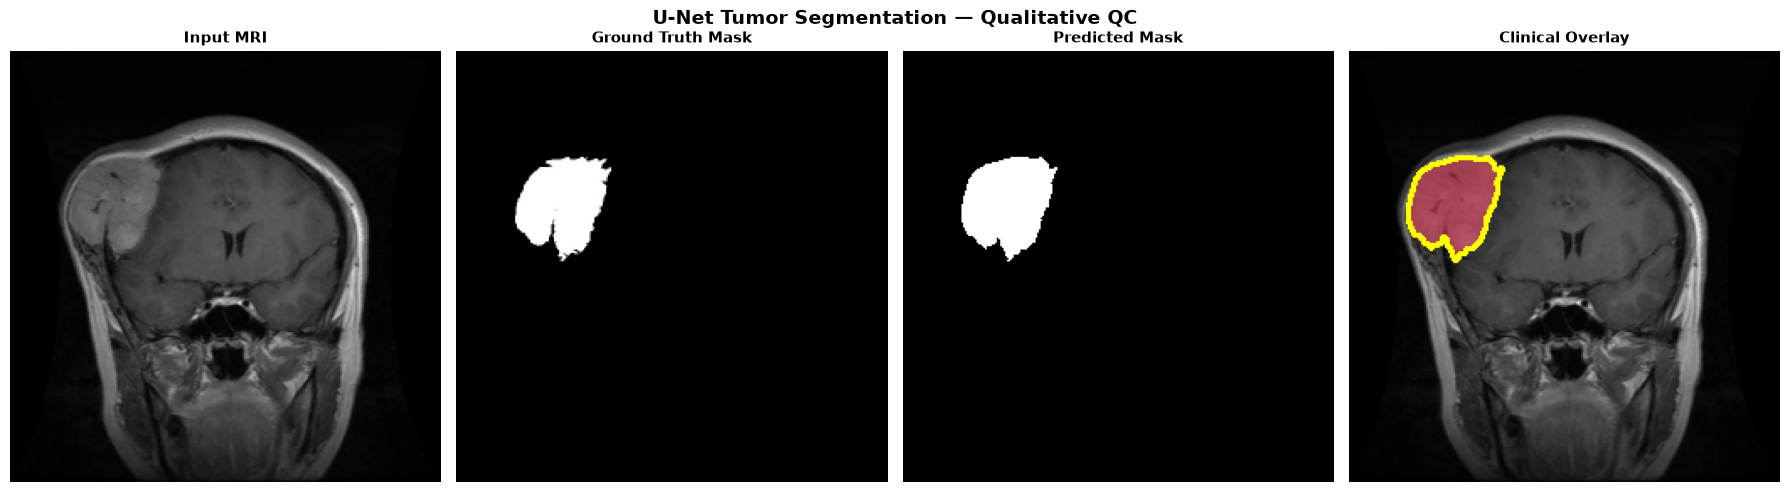

In [7]:
# ── Cell 7: Qualitative Segmentation Visualization ───────────────────────────
import torch, cv2, numpy as np, matplotlib.pyplot as plt, glob, os, random

from segmentation.unet_model import UNet

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = "checkpoints/unet/best_unet_enhanced.pth"

if not os.path.exists(CKPT_PATH):
    print(f"⚠️  Checkpoint not found: {CKPT_PATH}\nRun training (Cell 5) first.")
else:
    model = UNet(n_channels=3, n_classes=1).to(device)
    model.load_state_dict(torch.load(CKPT_PATH, map_location=device, weights_only=True))
    model.eval()
    print(f"✅ Loaded checkpoint: {CKPT_PATH}")

    # Pick a random validation sample
    import json
    with open("data/brisc/brisc_metadata.json") as f:
        meta = json.load(f)
    pairs = meta["segmentation"]
    random.seed(99)
    sample = random.choice(pairs)

    img_bgr  = cv2.imread(sample["image_path"])
    mask_gt  = cv2.imread(sample["mask_path"], cv2.IMREAD_GRAYSCALE)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rs   = cv2.resize(img_rgb, (256, 256))
    mask_rs  = cv2.resize(mask_gt, (256, 256))

    # Inference
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    tensor = torch.from_numpy(((img_rs / 255.0 - mean) / std).transpose(2, 0, 1)).float()
    tensor = tensor.unsqueeze(0).to(device)

    with torch.no_grad(), torch.amp.autocast("cuda", enabled=device.type == "cuda"):
        logits    = model(tensor)
        pred_prob = torch.sigmoid(logits).squeeze().cpu().numpy()
        pred_mask = (pred_prob > 0.5).astype(np.uint8) * 255

    # Clinical overlay: Crimson mask + yellow contour
    overlay = img_rs.copy()
    m = pred_mask > 0
    overlay[m] = (overlay[m] * 0.55 + np.array([255, 40, 80]) * 0.45).clip(0, 255).astype(np.uint8)
    contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (255, 255, 0), 2)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, img, title, cmap in zip(axes,
        [img_rs, mask_rs, pred_mask, overlay],
        ["Input MRI", "Ground Truth Mask", "Predicted Mask", "Clinical Overlay"],
        ["gray", "gray", "gray", None]):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")

    plt.suptitle("U-Net Tumor Segmentation — Qualitative QC", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("reports/figures/unet_qualitative.png", dpi=150)
    plt.show()